TypeError: can only concatenate str (not "int") to str

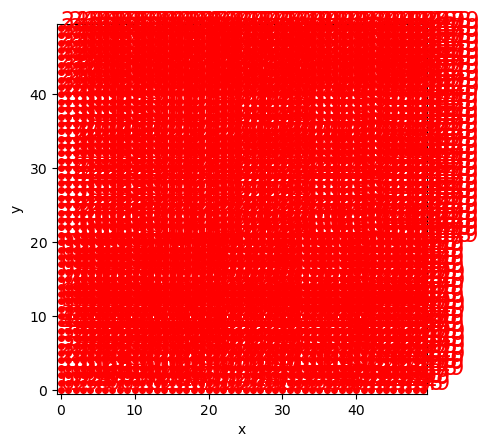

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.plot import plot_graph
#import geopanda as gpd

grid = RasterModelGrid((50, 50), 1)
plot_graph(grid, at="node")
topo = grid.add_zeros('topographic_elevation', at='node')
np.random.seed(0)  
grid_noise = np.random.rand(grid.number_of_nodes) / 1000.0
#grid += grid_noise
sea_level = 6.0
erosion_rate = 0.5  # or set zr[i] = sea_level to cut/flatten directly

# Loop over every node on the grid
for i in range((grid.number_of_nodes)+1):
    if grid[i] < sea_level:
        grid[i] -= erosion_rate  # Erode node if it is underwater
#for i in range(grid.number_of_node_rows):
    #cliff_height = 3
    #zr[i,:] = cliff_height
    #zr[mg.core_nodes] += uplift_length  # uplift the landscape

In [ ]:
dt = 1000  # time step [yr]
modeled_time = 0  # amount of time the landscape has evolved [yr]
time_to_run = 1e6  # time for the model loop to run [yr]

nsteps = int(time_to_run / dt)  # number of model time steps

uplift_rate = 2.1  # uplift rate [m/yr]
uplift_length = uplift_rate * dt # length of uplift per time step [m]